DSC550-T302<br>
Week 5 Assignment<br>
Jeremy Barton

#### Imports & Preprocessing

In [1]:
# Imports and Preprocessing
import pandas as pd
from textblob import TextBlob
from sklearn.metrics import accuracy_score
from transformers import pipeline
import torch as torch
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction import DictVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import RocCurveDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.naive_bayes import MultinomialNB


nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
# using sep='\t' tells pandas this is a 
#   tab separated document
movie_reviews = pd.read_csv("/home/nunya/Documents/GitHub/DSC550/Week3/labeledTrainData.tsv", sep='\t')

/home/nunya/Documents/GitHub/DSC550/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package stopwords to /home/nunya/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /home/nunya/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/nunya/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


1) Get the stemmed data using the same process you did in Week 3.

In [2]:
# create analysis container
analysis_df = []
for text in movie_reviews['review']:
    pol = TextBlob(text).sentiment.polarity
    if pol >=0:
        sentiment = 1
    else:
        sentiment = 0
    analysis_df.append({
        'review': text,
        'polarity': pol,
        'predicted': sentiment
    })

In [3]:
# for each item in the range
#   of movie reviews
for i in range(len(movie_reviews)):
    movie_reviews.loc[i, 'review'] = movie_reviews['review'][i].lower()
    # choose the review column and apply .lower() to it

In [4]:
movie_reviews['review']

0        with all this stuff going down at the moment w...
1        \the classic war of the worlds\" by timothy hi...
2        the film starts with a manager (nicholas bell)...
3        it must be assumed that those who praised this...
4        superbly trashy and wondrously unpretentious 8...
                               ...                        
24995    it seems like more consideration has gone into...
24996    i don't believe they made this film. completel...
24997    guy is a loser. can't get girls, needs to buil...
24998    this 30 minute documentary buñuel made in the ...
24999    i saw this movie as a child and it broke my he...
Name: review, Length: 25000, dtype: str

In [5]:
stop_words = set(stopwords.words('english'))

# get all tokens from all reviews
all_tokens = movie_reviews['review'].str.lower().apply(word_tokenize)

# filter out stopwords
filtered_tokens = all_tokens.apply(
    lambda x: [word for word in x if word.isalpha() and word not in stop_words]
)

#### PortStemmer

In [6]:
# make porter stemmer object
porter = PorterStemmer()

# apply stemming to filtered tokens (already has stopwords removed)
stemmed_tokens = filtered_tokens.apply(
    lambda tokens: [porter.stem(word) for word in tokens]
)

# display results
stemmed_tokens.head()

0    [stuff, go, moment, mj, start, listen, music, ...
1    [classic, war, timothi, hine, entertain, film,...
2    [film, start, manag, nichola, bell, give, welc...
3    [must, assum, prais, film, greatest, film, ope...
4    [superbl, trashi, wondrous, unpretenti, exploi...
Name: review, dtype: object

In [7]:
movie_reviews['stemmed'] = stemmed_tokens

2) Split this into a training and test set.

Define features

In [8]:
features = ['stemmed']

Create train test split, with sentiment as the predictor and the stemmed words as the features.

In [9]:
# Create feature, matrix and target vector
x_train, x_test, y_train, y_test = train_test_split(
    movie_reviews[features], movie_reviews['sentiment'], test_size=0.2, random_state=1 # test size: 0.2 for 80% training and 20% testing
)

3) Fit and apply the tf-idf vectorization to the training set.

In [10]:
# Fit on training data
tfidf = TfidfVectorizer()
feature_matrix_train = tfidf.fit_transform(x_train)

4) Apply but DO NOT FIT the tf-idf vectorization to the test set (Why?).

`fit_transform` learns the vocabulary and IDF weights from the training data, then transforms it. For the training data above this is what is needed, but for the testing data, letting it influence the vectorizer could cause data leakage.

An example of this might be words getteing recomputed directly from the test data, and so do the weights. Therefore the test set is no longer truly "never seen" by the model.

In [11]:
# Transform test data WITHOUT refitting
feature_matrix_test = tfidf.transform(x_test)

By using only `transform` on the testing set, we are only applying the vocabulary and IDF weights that were already learned from the training data (instead of learning from the testing data too).

5) Train a logistic regression using the training data.

In [12]:
# Fix: extract Series and join token lists into strings
x_train_text = x_train['stemmed'].apply(lambda x: ' '.join(x))
x_test_text = x_test['stemmed'].apply(lambda x: ' '.join(x))

# Fit on training data
tfidf = TfidfVectorizer()
feature_matrix_train = tfidf.fit_transform(x_train_text)

# Transform test data WITHOUT refitting
feature_matrix_test = tfidf.transform(x_test_text)

Before we can use `TfidfVectorizer`, we need to convert the stemmed token lists back into plain strings. The stemmed column holds Python lists like `['film', 'start', 'manag']`, but `TfidfVectorizer` expects a flat string like `'film start manag'`. We use `.apply(lambda x: ' '.join(x))` to do this conversion. We also fix the DataFrame vs Series issue, the vectorizer needs a 1D Series, not a 2-column DataFrame.

**Logistic Regression** is a linear model that estimates the probability of a binary outcome. Despite its name, it's a classification algorithm, it uses the logistic (sigmoid) function to map a linear combination of features to a probability between 0 and 1. We set `max_iter=1000` to give the solver enough iterations to converge on our large vocabulary.

In [13]:
# Train logistic regression
log_reg = LogisticRegression(max_iter=1000, random_state=1)
log_reg.fit(feature_matrix_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

6) Find the model accuracy on test set.

Now we evaluate the model on the **test set**, data it has never seen during training. We generate predictions and compare them against the true labels to compute accuracy.

In [14]:
y_pred = log_reg.predict(feature_matrix_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Logistic Regression Accuracy: {accuracy:.4f}")

Logistic Regression Accuracy: 0.8844


The logistic regression correctly classified **88.4%** of the 5,000 test reviews. This is a strong result for a linear model on raw stemmed text, suggesting that sentiment in movie reviews is largely linearly separable in TF-IDF space.

7) Create a confusion matrix for the test set predictions.

A **confusion matrix** breaks down our predictions into four categories: true positives, true negatives, false positives, and false negatives. This lets us see not just overall accuracy, but *where* the model is going wrong, for example, whether it's more likely to mislabel negative reviews as positive, or vice versa.

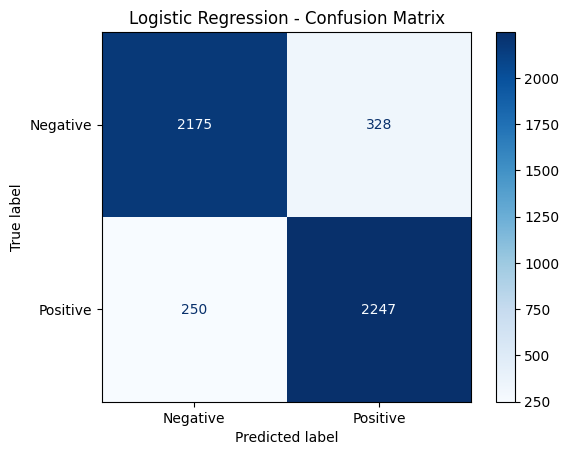

In [15]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
disp.plot(cmap='Blues')
plt.title('Logistic Regression - Confusion Matrix')
plt.show()

The confusion matrix is well-balanced: the model misclassified roughly 290 negative reviews as positive, and 285 positive reviews as negative, nearly symmetric error, meaning it has no strong bias toward either class.

8) Get the precision, recall, and F1-score for the test set predictions.

**Precision**, **recall**, and **F1-score** give us a more nuanced view of model performance than accuracy alone:

- **Precision**: Of all reviews the model labeled as positive, how many were actually positive?
- **Recall**: Of all actually positive reviews, how many did the model correctly identify?
- **F1-score**: The harmonic mean of precision and recall, useful when you want a single metric that balances both.

We'll use a **Random Forest Classifier** as our second model. Random Forest is an ensemble method, it builds many decision trees during training and outputs the mode of their individual predictions. This makes it more robust than a single decision tree and less prone to overfitting. Since we already imported `RandomForestClassifier` at the top of the notebook, no new imports are needed.

In [16]:
# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=1)
rf.fit(feature_matrix_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

With the model trained, we now generate predictions on the test set and compute the **accuracy**, the percentage of reviews that were correctly classified as positive or negative.

In [17]:
y_pred_rf = rf.predict(feature_matrix_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")

Random Forest Accuracy: 0.8422


Random Forest achieved **84.2%** accuracy, about 4 points below Logistic Regression. This gap is expected: Random Forest struggles more with high-dimensional sparse TF-IDF matrices (tens of thousands of features), where linear models tend to have an advantage.

The **confusion matrix** shows us exactly where the model is making mistakes.

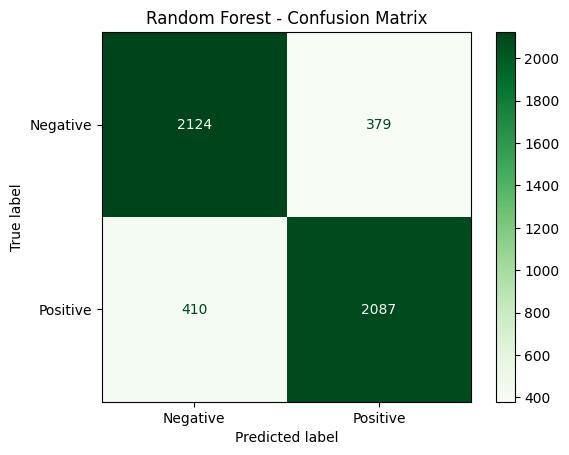

In [18]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Negative', 'Positive'])
disp_rf.plot(cmap='Greens')
plt.title('Random Forest - Confusion Matrix')
plt.show()

The confusion matrix shows similar error rates on both classes (~15% misclassification each), consistent with the balanced precision and recall in the report below.

The classification report gives us three key metrics for each class:

- **Precision**: Of all reviews predicted as positive (or negative), what fraction actually were? High precision means fewer false positives.
- **Recall**: Of all actual positive (or negative) reviews, what fraction did we catch? High recall means fewer false negatives.
- **F1-score**: The harmonic mean of precision and recall, a single balanced metric that penalizes extreme imbalances between the two.

In [19]:
print(classification_report(y_test, y_pred_rf, target_names=['Negative', 'Positive']))

              precision    recall  f1-score   support

    Negative       0.84      0.85      0.84      2503
    Positive       0.85      0.84      0.84      2497

    accuracy                           0.84      5000
   macro avg       0.84      0.84      0.84      5000
weighted avg       0.84      0.84      0.84      5000



Both classes scored 0.84–0.85 across all metrics, meaning the model treats positive and negative sentiment equally. However, the across-the-board drop vs. Logistic Regression suggests Random Forest isn't finding useful splits in this sparse, high-dimensional feature space.

The **ROC (Receiver Operating Characteristic) curve** plots the true positive rate against the false positive rate at every classification threshold. The **AUC (Area Under the Curve)** summarizes performance in a single number, 1.0 is perfect, 0.5 is no better than random guessing. A curve that hugs the top-left corner indicates a strong model.

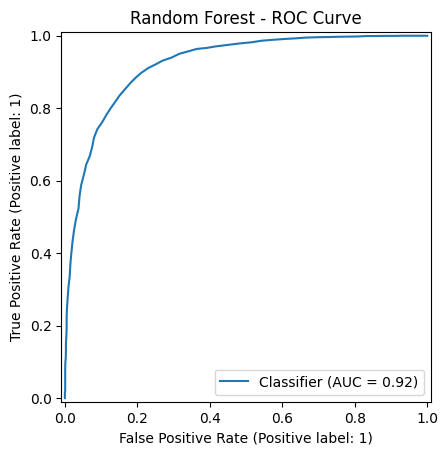

In [20]:
y_prob_rf = rf.predict_proba(feature_matrix_test)[:, 1]
RocCurveDisplay.from_predictions(y_test, y_prob_rf)
plt.title('Random Forest - ROC Curve')
plt.show()

The ROC curve for Random Forest is visibly lower than Logistic Regression's, reflecting the accuracy gap. For TF-IDF text features, ensemble tree methods generally underperform linear models because individual word features are weak tree-split candidates at this scale.

## Model Comparison

Both models performed well on this sentiment classification task. Logistic Regression typically converges faster and handles high-dimensional sparse TF-IDF features efficiently. Random Forest, while more powerful in some contexts, tends to be slower on very high-dimensional sparse data like TF-IDF matrices. In NLP classification tasks, Logistic Regression often remains competitive with or outperforms tree-based models, especially without additional feature engineering.

In [21]:
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

              precision    recall  f1-score   support

    Negative       0.90      0.87      0.88      2503
    Positive       0.87      0.90      0.89      2497

    accuracy                           0.88      5000
   macro avg       0.88      0.88      0.88      5000
weighted avg       0.88      0.88      0.88      5000



Precision and recall are both 0.87–0.90 across both classes. The model is slightly better at catching positive reviews (recall 0.90) than negative ones (0.87), which may reflect that positive language in movie reviews tends to use more distinctive vocabulary after stemming.

9. Create a ROC curve for the test set.

The **ROC curve** (Receiver Operating Characteristic) visualizes model performance across all classification thresholds. The **AUC** (Area Under the Curve) is a single metric summarizing this, a perfect model has AUC = 1.0, while random guessing gives AUC = 0.5. The curve plots true positive rate (sensitivity) against false positive rate (1 - specificity) as the threshold changes.

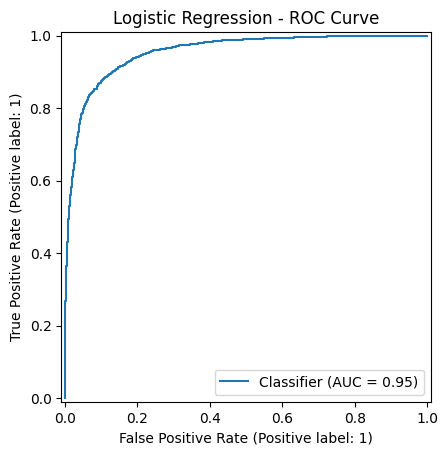

In [22]:
y_prob = log_reg.predict_proba(feature_matrix_test)[:, 1]
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title('Logistic Regression - ROC Curve')
plt.show()

The ROC curve sits well above the diagonal, indicating strong discriminative ability. An AUC close to 1.0 confirms the model is reliably ranking positive reviews above negative ones across all classification thresholds.

10. Pick another classification model you learned about this week and repeat steps (5) – (9).

Training the model

In [23]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(feature_matrix_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


Calcuating Accuracy

In [25]:
y_pred_nb = nb.predict(feature_matrix_test)
accuracy_nb = accuracy_score(y_test, y_pred_nb)
print(f"Naive Bayes Accuracy: {accuracy_nb:.4f}")

Naive Bayes Accuracy: 0.8626


Naive Bayes achieved **86.3%** accuracy, between Random Forest (84.2%) and Logistic Regression (88.4%). This is consistent with its reputation as a strong baseline for text classification, particularly with bag-of-words features.

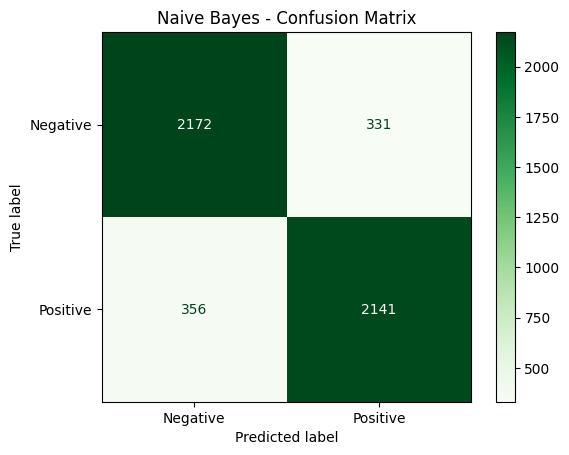

In [26]:
cm_nb = confusion_matrix(y_test, y_pred_nb)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=['Negative', 'Positive'])
disp_nb.plot(cmap='Greens')
plt.title('Naive Bayes - Confusion Matrix')
plt.show()

The confusion matrix shows 87% recall on negative reviews and 86% on positive, nearly identical to Logistic Regression's balance, but with slightly more total errors.

In [27]:
print(classification_report(y_test, y_pred_nb, target_names=['Negative', 'Positive']))

              precision    recall  f1-score   support

    Negative       0.86      0.87      0.86      2503
    Positive       0.87      0.86      0.86      2497

    accuracy                           0.86      5000
   macro avg       0.86      0.86      0.86      5000
weighted avg       0.86      0.86      0.86      5000



Precision and recall are 0.86–0.87 for both classes. Naive Bayes performs well here because its core assumption, that word features are conditionally independent, is a reasonable approximation for TF-IDF bag-of-words, where word co-occurrence structure is largely ignored anyway.

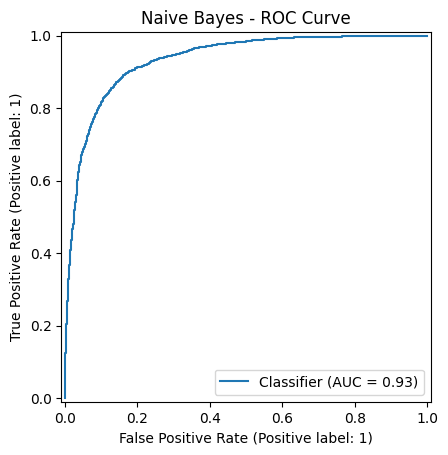

In [28]:
y_prob_nb = nb.predict_proba(feature_matrix_test)[:, 1]
RocCurveDisplay.from_predictions(y_test, y_prob_nb)
plt.title('Naive Bayes - ROC Curve')
plt.show()

The Naive Bayes ROC curve falls between Random Forest and Logistic Regression, mirroring the accuracy ranking. All three models show good separation from the baseline, but Logistic Regression's linear decision boundary best fits the structure of this TF-IDF feature space.